# Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import re
import os
import gdown as gd
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Data Loading

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-electronics-store")

print(os.listdir(path))

Using Colab cache for faster access to the 'ecommerce-events-history-in-electronics-store' dataset.
['events.csv']


In [ ]:
df = pd.read_csv(
    path + "/events.csv"
)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


# Data Understanding

In [ ]:
df.shape

(885129, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [ ]:
df.duplicated().sum()

np.int64(655)

In [ ]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,236219
brand,212364
price,0
user_id,0
user_session,165


In [ ]:
df['event_type'].value_counts()

,count
event_type,
view,793748
cart,54035
purchase,37346


# Data Pre-Processing

## Data Cleaning / Manipulation

In [ ]:
# 1. drop duplicated data

data_clean = df.copy()

data_clean.drop_duplicates(inplace=True)
data_clean.duplicated().sum()

np.int64(0)

In [ ]:
# 2. Change event_time from object to datetime type

data_clean['event_time'] = pd.to_datetime(data_clean['event_time']).dt.tz_localize(None)
data_clean.dtypes

,0
event_time,datetime64[ns]
event_type,object
product_id,int64
category_id,int64
category_code,object
brand,object
price,float64
user_id,int64
user_session,object


In [ ]:
data_clean.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


## Data Validation

In [ ]:
data_clean.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,236047
brand,212232
price,0
user_id,0
user_session,162


In [ ]:
# 1. Mapping category_code with category_id

mapping_category = (
    data_clean.dropna(subset=['category_code'])
      .drop_duplicates('category_id')
      .set_index('category_id')['category_code']
)

missing_code = data_clean['category_code'].isna()

can_be_mapped = (
    missing_code &
    data_clean['category_id'].isin(mapping_category.index)
)

print("Missing category_code :", missing_code.sum())
print("Can be mapped         :", can_be_mapped.sum())

Missing category_code : 236047
Can be mapped         : 0


In [ ]:
# 2. Mapping brand with product_id

mapping_brand = (
    data_clean.dropna(subset=['brand'])
      .drop_duplicates('product_id')
      .set_index('product_id')['brand']
)

missing_brand = data_clean['brand'].isna()

can_be_mapped = (
    missing_brand &
    data_clean['product_id'].isin(mapping_brand.index)
)

print("Missing brand :", missing_brand.sum())
print("Can be mapped :", can_be_mapped.sum())

Missing brand : 212232
Can be mapped : 0


Finding:
*  Missing values in category_code and brand could not be recovered through ID-based mapping. Hence, the records with missing values in these colomns will be excluded from further analysis.

* Missing values in user_session will also be removed because session identification is essential for funnel analysis.

## Missing Value Handling

In [ ]:
# Remove missing values in 3 columns
data_clean = data_clean.dropna(subset=['category_code', 'brand', 'user_session'])

data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515855 entries, 1 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   event_time     515855 non-null  datetime64[ns]
 1   event_type     515855 non-null  object        
 2   product_id     515855 non-null  int64         
 3   category_id    515855 non-null  int64         
 4   category_code  515855 non-null  object        
 5   brand          515855 non-null  object        
 6   price          515855 non-null  float64       
 7   user_id        515855 non-null  int64         
 8   user_session   515855 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 39.4+ MB


## Feature Engineering

In [ ]:
# extract time

data_clean['event_date'] = data_clean['event_time'].dt.date
data_clean['event_day'] = data_clean['event_time'].dt.day_name()
data_clean['event_hour'] = data_clean['event_time'].dt.strftime('%H:%M')

data_clean.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_hour
1,2020-09-24 11:57:26,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020-09-24,Thursday,11:57
3,2020-09-24 11:57:33,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020-09-24,Thursday,11:57
5,2020-09-24 11:57:59,view,664325,2144415951611757447,construction.tools.saw,carver,52.33,1515915625519388062,vnkdP81DDW,2020-09-24,Thursday,11:57
7,2020-09-24 11:58:24,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kVBeYDPcBw,2020-09-24,Thursday,11:58
9,2020-09-24 11:58:31,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388929,F3VB9LYp39,2020-09-24,Thursday,11:58


# EDA

##1.Distribution Overview

###a. Events Distribution

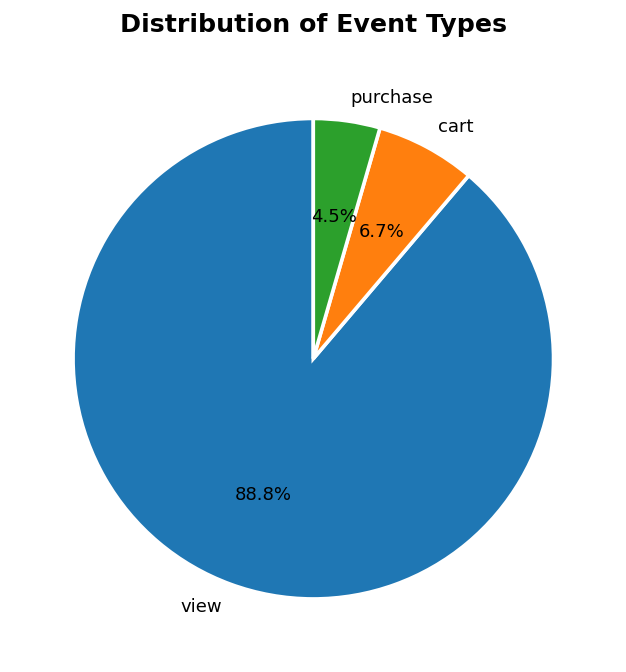

In [ ]:
event_counts = data_clean['event_type'].value_counts()

plt.figure(figsize=(6, 6), dpi=130)

plt.pie(
    event_counts,
    labels=event_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title(
    'Distribution of Event Types',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# plt.savefig(
#     "event_distribution.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

In [ ]:
unique_users = data_clean['user_id'].nunique()

print(f"Unique Users: {unique_users:,}")

Unique Users: 224,971


In [ ]:
unique_sessions = data_clean['user_session'].nunique()

print(f"Unique Sessions: {unique_sessions:,}")

Unique Sessions: 273,421


In [ ]:
unique_products = data_clean['product_id'].nunique()

print(f"Total Products: {unique_products:,}")

Total Products: 24,255


In [ ]:
print(data_clean["user_id"].dtype)
print(data_clean["user_id"].nunique())

print(
    data_clean["user_id"]
    .astype(str)
    .nunique()

    )

int64
224971
224971


In [ ]:
summary = pd.DataFrame({
    'Metric': ['Total Events', 'Unique Users', 'Unique Sessions'],
    'Value': [
        len(data_clean),
        data_clean['user_id'].nunique(),
        data_clean['user_session'].nunique()
    ]
})

summary

,Metric,Value
0,Total Events,515855
1,Unique Users,224971
2,Unique Sessions,273421


###b. Price Distribution

In [ ]:
data_clean["price"].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

,price
count,"515,855.00"
mean,188.92
std,347.60
min,0.90
25%,45.24
50%,105.87
75%,249.38
90%,461.52
95%,577.60
99%,"1,029.06"


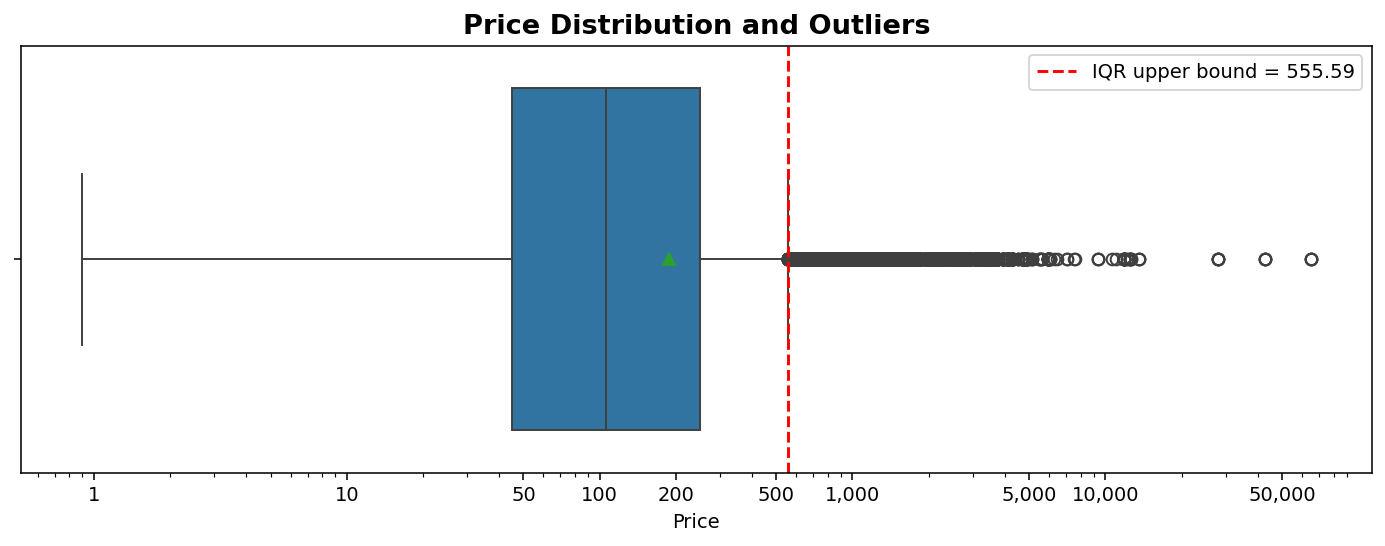

In [ ]:
Q1 = data_clean["price"].quantile(0.25)
Q3 = data_clean["price"].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(10, 4), dpi=140)

sns.boxplot(
    x=data_clean["price"],
    showmeans=True
)

plt.xscale("log")

# Harga yang ingin ditampilkan pada axis
price_ticks = [1, 10, 50, 100, 200, 500, 1000, 5000, 10000, 50000]

plt.xticks(
    price_ticks,
    [f"{x:,}" for x in price_ticks]
)

plt.axvline(
    upper_bound,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"IQR upper bound = {upper_bound:.2f}"
)

plt.title(
    "Price Distribution and Outliers",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price")
plt.ylabel("")

plt.legend()

plt.tight_layout()
plt.show()

Interpretation:

> Price distribution is very right-skewed with a mean price is 188.92 and a long upper tail.

* 75% data ≤ 249.38
* 90% data ≤ 461.52
* 95% data ≤ 577.60
* 99% data ≤ 1,029.06
* Maximum = 64,771.06

Meaning:
* Q1 = 45.24
* Median = 105.67
* Q3 = 249.38
* IQR = 204.14
* Upper IQR fence = 555.59
* Max = 64,771.06

Based on the IQR rule, prices above 555.59 are statistical outliers.

And because the wide range of price, using log-scale transformation was applied for better visualization of price distribution.

........

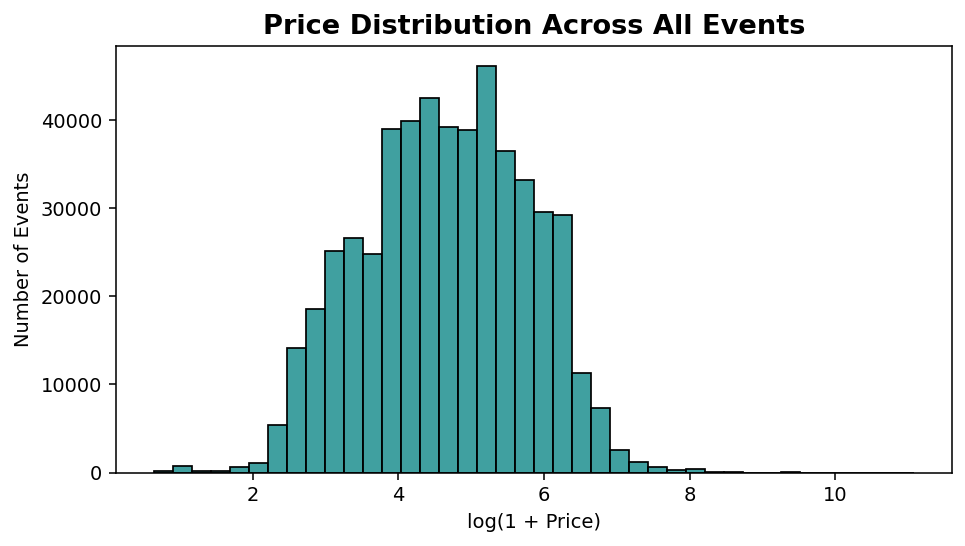

In [ ]:
plt.figure(figsize=(7, 4), dpi=140)

sns.histplot(
    np.log1p(data_clean["price"]),
    bins=40,
    color="teal"
)

plt.title(
    "Price Distribution Across All Events",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("log(1 + Price)")
plt.ylabel("Number of Events")

plt.tight_layout()

# plt.savefig(
#     "price_log.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

In [ ]:
# price distribution based on users

bins = [
    0,
    25,
    50,
    100,
    200,
    500,
    1000,
    float("inf")
]

labels = [
    "0–25",
    "25–50",
    "50–100",
    "100–200",
    "200–500",
    "500–1K",
    "1K+"
]

data_clean["price_band"] = pd.cut(
    data_clean["price"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

price_distribution = (
    data_clean
    .groupby("price_band", observed=True)
    .agg(
        Events=("price", "size"),
        Unique_Users=("user_id", "nunique")
    )
    .reset_index()
)

price_distribution

,price_band,Events,Unique_Users
0,0–25,67083,40496
1,25–50,72853,42299
2,50–100,108557,54467
3,100–200,97438,46782
4,200–500,134614,51403
5,500–1K,29930,12761
6,1K+,5380,3711


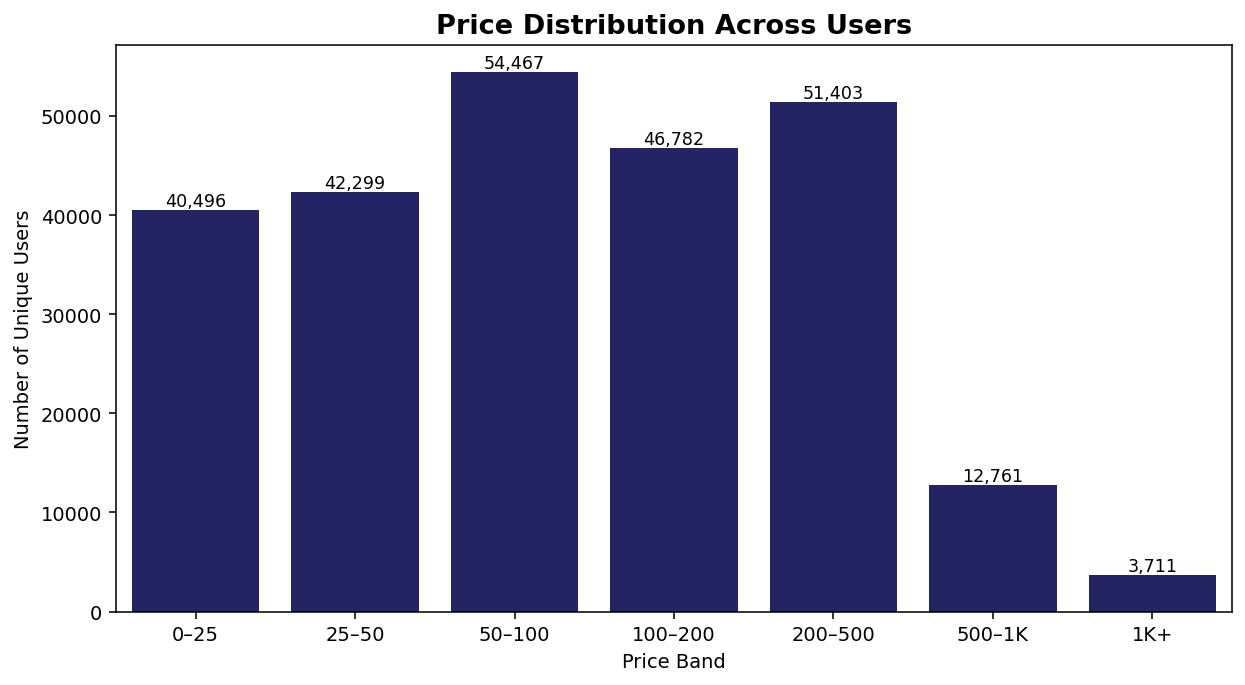

In [ ]:
plt.figure(figsize=(9, 5), dpi=140)

sns.barplot(
    data=price_distribution,
    x="price_band",
    y="Unique_Users",
    color="midnightblue"
)

plt.title(
    "Price Distribution Across Users",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price Band")
plt.ylabel("Number of Unique Users")

for i, value in enumerate(price_distribution["Unique_Users"]):
    plt.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# plt.savefig(
#     "price_distribution.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

# Funnel Analysis
> Q: Where do users exit the purchase journey?

Variables:
* User ID
* Event Type

In [ ]:
# User Funnel

data_clean.groupby("event_type")["user_id"].nunique()

,user_id
event_type,
cart,23158
purchase,13041
view,224741


In [ ]:
event_order = [
    "view",
    "cart",
    "purchase"
]

data_clean["event_order"] = pd.Categorical(
    data_clean["event_type"],
    categories=event_order,
    ordered=True
)

data_sorted = data_clean.sort_values(["user_id", "event_time"])

user_events = (
    data_sorted[data_sorted["event_type"].isin(event_order)]
    .groupby(["user_id", "event_type"])["event_time"]
    .min()
    .unstack()
    .reindex(columns=event_order)
)

user_events.head()

event_type,view,cart,purchase
user_id,,,
1515915625353226922,2020-10-29 11:28:35,NaT,NaT
1515915625353230683,2020-11-09 08:52:51,NaT,NaT
1515915625353230922,2020-10-02 08:23:40,NaT,NaT
1515915625353234047,2020-09-29 16:01:54,NaT,NaT
1515915625353236157,2021-02-11 15:50:40,NaT,NaT


##1.Conversion Rate

In [ ]:
# Count unique users for each event

N_view = data_clean.loc[
    data_clean["event_type"] == "view", "user_id"
].nunique()

N_cart = data_clean.loc[
    data_clean["event_type"] == "cart", "user_id"
].nunique()

N_purchase = data_clean.loc[
    data_clean["event_type"] == "purchase", "user_id"
].nunique()


# Conversion rate
conversion_table = pd.DataFrame({
    "transition": [
        "view → cart",
        "cart → purchase",
        "view → purchase"
    ],
    "conversion": [
        N_cart / N_view if N_view else np.nan,
        N_purchase / N_cart if N_cart else np.nan,
        N_purchase / N_view if N_view else np.nan
    ]
})

# Drop-off rate
conversion_table["dropoff"] = (
    1 - conversion_table["conversion"]
)

display(conversion_table)

,transition,conversion,dropoff
0,view → cart,0.10,0.90
1,cart → purchase,0.56,0.44
2,view → purchase,0.06,0.94


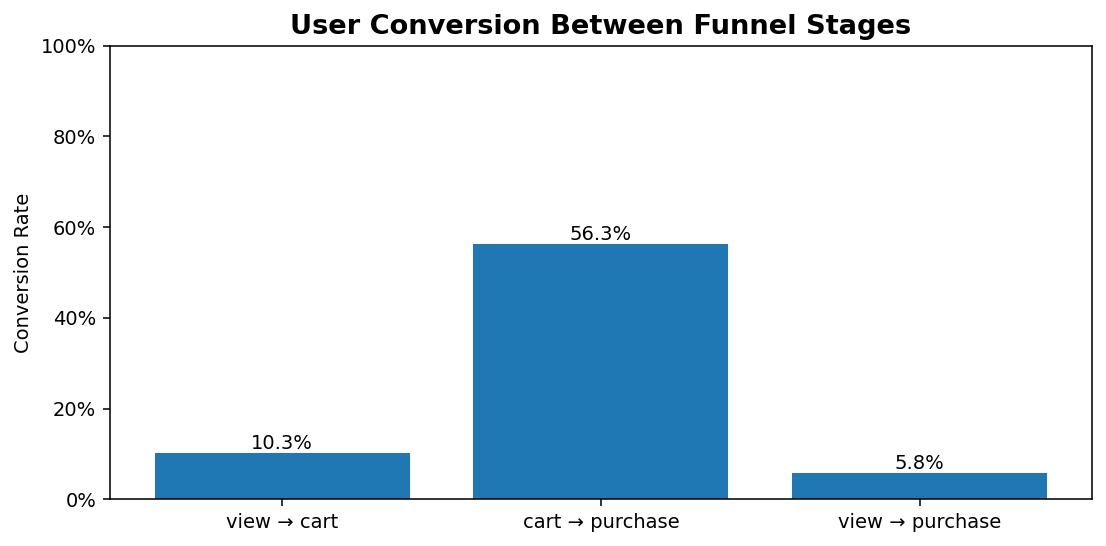

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=140)

ax.bar(
    conversion_table["transition"],
    conversion_table["conversion"]
)

ax.set_title(
    "User Conversion Between Funnel Stages",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Conversion Rate")
ax.set_ylim(0, 1)

# Format Y-axis as percentage
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

# Add percentage labels
for i, value in enumerate(conversion_table["conversion"]):
    ax.text(
        i,
        value,
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# plt.savefig(
#     "funnel.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

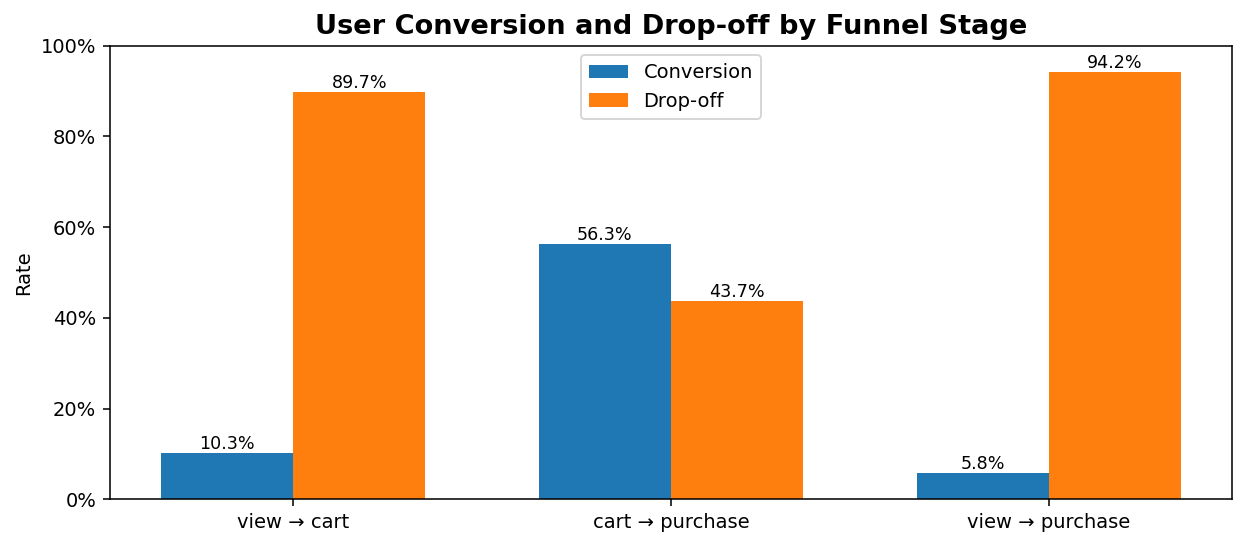

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=140)

x = np.arange(len(conversion_table))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    conversion_table["conversion"],
    width,
    label="Conversion"
)

bars2 = ax.bar(
    x + width/2,
    conversion_table["dropoff"],
    width,
    label="Drop-off"
)

ax.set_title(
    "User Conversion and Drop-off by Funnel Stage",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Rate")
ax.set_xticks(x)
ax.set_xticklabels(conversion_table["transition"])
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.legend()

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

> Interpretation:
* view → purchase : overall user conversion
* view → cart & cart → purchase are conversion for each funnel transition

> Finding :

The largest drop-off is observed between View and Cart (89.7%), while the highest conversion is Cart-to-Purchase (56.3%).

##2.Drop-off Drivers
> Q: Why do users drop off between View and Cart?

> Q: Are certain price levels, categories, and brands associated with higher drop-off?

Variables:
* Price
* Category
* Brand

####a. Price

In [ ]:
price_funnel = (
    data_clean[
        data_clean["event_type"].isin(["view", "cart", "purchase"])
    ]
    .groupby(["price_band", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["view", "cart", "purchase"], fill_value=0)
    .reset_index()
)

price_funnel.head(10)

event_type,price_band,view,cart,purchase
0,0–25,40457,2750,1755
1,25–50,42258,3216,2027
2,50–100,54425,4619,2514
3,100–200,46748,4577,2491
4,200–500,51329,8040,4090
5,500–1K,12734,1656,856
6,1K+,3710,115,50


In [ ]:
# view_to_cart conversion & drop-off

price_funnel["view_to_cart_conversion"] = (
    price_funnel["cart"] /
    price_funnel["view"] *
    100
)

price_funnel["view_to_cart_dropoff"] = (
    100 - price_funnel["view_to_cart_conversion"]
)

price_funnel

event_type,price_band,view,cart,purchase,view_to_cart_conversion,view_to_cart_dropoff
0,0–25,40457,2750,1755,6.80,93.20
1,25–50,42258,3216,2027,7.61,92.39
2,50–100,54425,4619,2514,8.49,91.51
3,100–200,46748,4577,2491,9.79,90.21
4,200–500,51329,8040,4090,15.66,84.34
5,500–1K,12734,1656,856,13.00,87.00
6,1K+,3710,115,50,3.10,96.90


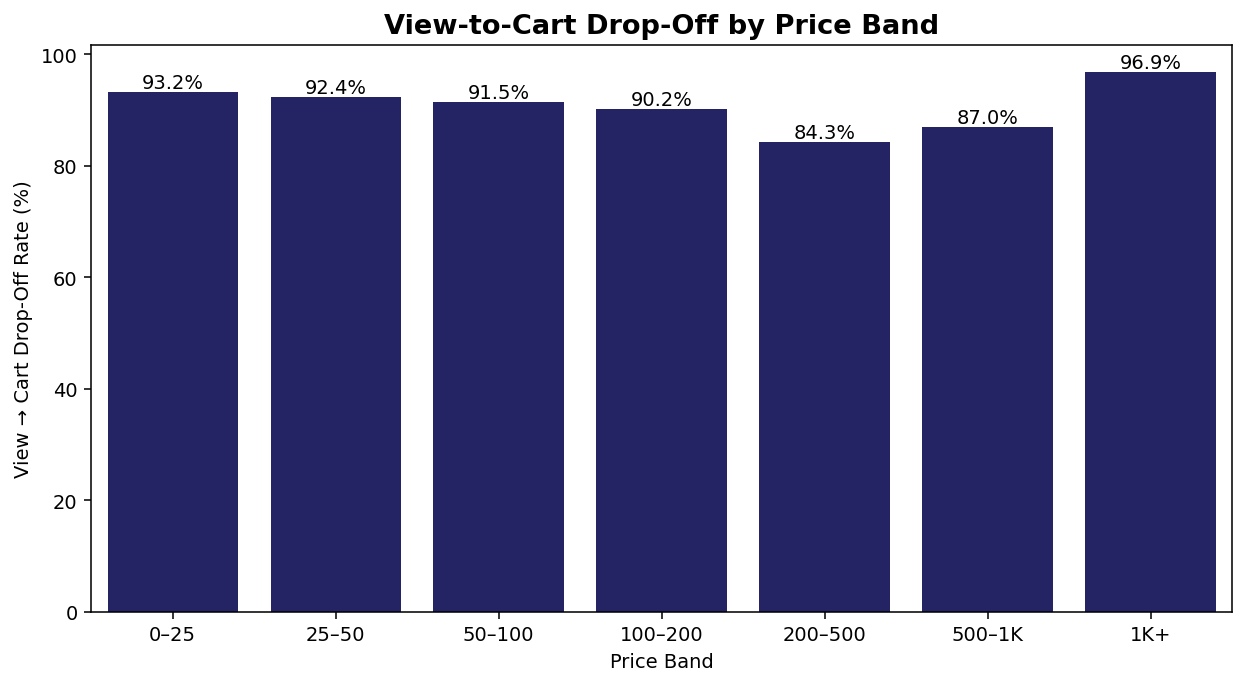

In [ ]:
plt.figure(figsize=(9, 5), dpi=140)

sns.barplot(
    data=price_funnel,
    x="price_band",
    y="view_to_cart_dropoff",
    color="midnightblue"
)

plt.title(
    "View-to-Cart Drop-Off by Price Band",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price Band")
plt.ylabel("View → Cart Drop-Off Rate (%)")

for i, value in enumerate(price_funnel["view_to_cart_dropoff"]):
    plt.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# cart_to_purchase conversion & drop-off

cart_purchase = (
    data_clean[
        data_clean["event_type"].isin(["cart", "purchase"])
    ]
    .groupby(["price_band", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["cart", "purchase"], fill_value=0)
    .reset_index()
)

cart_purchase

event_type,price_band,cart,purchase
0,0–25,2750,1755
1,25–50,3216,2027
2,50–100,4619,2514
3,100–200,4577,2491
4,200–500,8040,4090
5,500–1K,1656,856
6,1K+,115,50


In [ ]:
cart_purchase["conversion_rate"] = (
    cart_purchase["purchase"] /
    cart_purchase["cart"] * 100
)

cart_purchase["dropoff_rate"] = (
    100 - cart_purchase["conversion_rate"]
)

cart_purchase.sort_values(
    "conversion_rate",
    ascending=False
)

event_type,price_band,cart,purchase,conversion_rate,dropoff_rate
0,0–25,2750,1755,63.82,36.18
1,25–50,3216,2027,63.03,36.97
2,50–100,4619,2514,54.43,45.57
3,100–200,4577,2491,54.42,45.58
5,500–1K,1656,856,51.69,48.31
4,200–500,8040,4090,50.87,49.13
6,1K+,115,50,43.48,56.52


In [ ]:
price_conversion  = (
    price_funnel[
        ["price_band", "view", "cart", "view_to_cart_conversion"]
    ]
    .merge(
        cart_purchase[
            ["price_band", "purchase", "conversion_rate"]
        ],
        on="price_band"
    )
)

price_conversion.rename(
    columns={
        "conversion_rate": "cart_to_purchase_conversion"
    },
    inplace=True
)

# View → Purchase conversion
price_conversion["view_to_purchase_conversion"] = (
    price_conversion["purchase"] /
    price_conversion["view"] * 100
)

price_conversion

event_type,price_band,view,cart,view_to_cart_conversion,purchase,cart_to_purchase_conversion,view_to_purchase_conversion
0,0–25,40457,2750,6.80,1755,63.82,4.34
1,25–50,42258,3216,7.61,2027,63.03,4.80
2,50–100,54425,4619,8.49,2514,54.43,4.62
3,100–200,46748,4577,9.79,2491,54.42,5.33
4,200–500,51329,8040,15.66,4090,50.87,7.97
5,500–1K,12734,1656,13.00,856,51.69,6.72
6,1K+,3710,115,3.10,50,43.48,1.35


In [ ]:
dropoff_matrix = price_conversion[
    ["price_band",
     "view_to_cart_conversion",
     "cart_to_purchase_conversion"]
].copy()

dropoff_matrix["View → Cart"] = (
    100 - dropoff_matrix["view_to_cart_conversion"]
)

dropoff_matrix["Cart → Purchase"] = (
    100 - dropoff_matrix["cart_to_purchase_conversion"]
)

dropoff_matrix = dropoff_matrix.set_index("price_band")[
    [
        "View → Cart",
        "Cart → Purchase"
    ]
]

dropoff_matrix

event_type,View → Cart,Cart → Purchase
price_band,,
0–25,93.20,36.18
25–50,92.39,36.97
50–100,91.51,45.57
100–200,90.21,45.58
200–500,84.34,49.13
500–1K,87.00,48.31
1K+,96.90,56.52


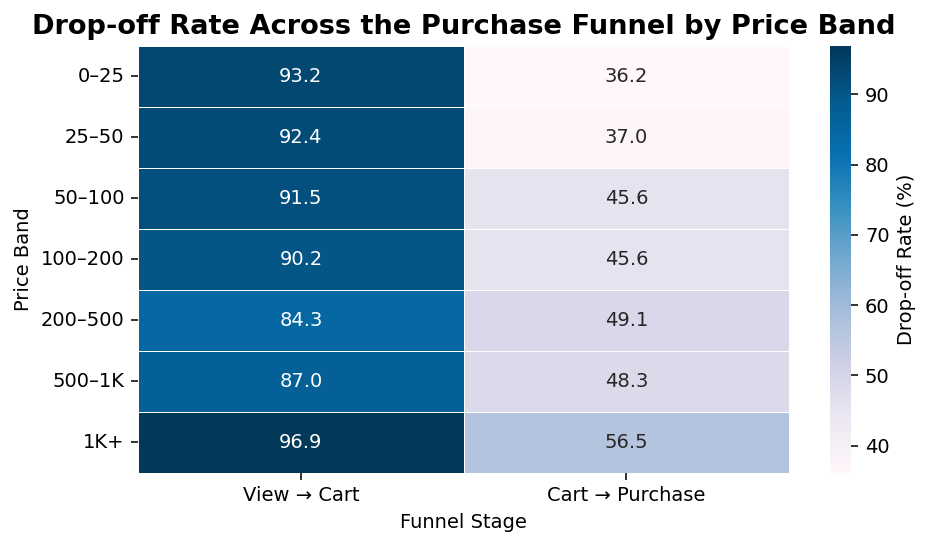

In [ ]:
plt.figure(figsize=(7, 4), dpi=140)

sns.heatmap(
    dropoff_matrix,
    annot=True,
    fmt=".1f",
    cmap="PuBu",
    linewidths=0.5,
    cbar_kws={"label": "Drop-off Rate (%)"}
)

plt.title(
    "Drop-off Rate Across the Purchase Funnel by Price Band",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Price Band")

plt.tight_layout()
plt.show()

####b. Category

In [ ]:
category_analysis = (
    data_clean[data_clean["event_type"].isin(["view", "cart", "purchase"])]
    .groupby(["category_code", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["view", "cart", "purchase"], fill_value=0)
    .reset_index()
)

category_analysis.head()

event_type,category_code,view,cart,purchase
0,accessories.bag,1103,52,32
1,apparel.glove,42,1,0
2,appliances.environment.air_heater,488,15,9
3,appliances.environment.fan,59,1,0
4,appliances.environment.vacuum,3491,239,174


In [ ]:
# make sure users follow the funnel view -> cart -> purchase

category_sorted = data_clean.sort_values(
    ["user_id", "event_time"]
).copy()

category_events = (
    category_sorted[
        category_sorted["event_type"].isin(["view", "cart", "purchase"])
    ]
    .groupby(
        ["user_id", "category_code", "event_type"]
    )["event_time"]
    .min()
    .unstack()
    .reindex(columns=["view", "cart", "purchase"], fill_value=0)
    .reset_index()
)

category_events.head()

event_type,user_id,category_code,view,cart,purchase
0,1515915625353226922,electronics.clocks,2020-10-29 11:28:35,NaT,NaT
1,1515915625353230683,computers.peripherals.printer,2020-12-12 10:33:09,NaT,NaT
2,1515915625353230683,electronics.audio.acoustic,2020-11-09 08:52:51,NaT,NaT
3,1515915625353230922,computers.components.videocards,2020-10-02 08:23:40,NaT,NaT
4,1515915625353234047,electronics.audio.headphone,2020-10-10 07:54:05,NaT,NaT


In [ ]:
category_events = category_events[
    category_events["category_code"].notna()
].copy()

category_events["view_to_cart"] = (
    category_events["view"].notna() &
    category_events["cart"].notna() &
    (category_events["cart"] > category_events["view"])
)

category_events["cart_to_purchase"] = (
    category_events["cart"].notna() &
    category_events["purchase"].notna() &
    (category_events["purchase"] > category_events["cart"])
)

category_funnel = (
    category_events
    .groupby("category_code")
    .agg(
        view_users=("view", "count"),
        cart_users=("view_to_cart", "sum"),
        purchase_users=("cart_to_purchase", "sum")
    )
    .reset_index()
)
category_funnel.sort_values(
    "view_users",
    ascending=False
).head(10)

,category_code,view_users,cart_users,purchase_users
87,electronics.telephone,25338,1789,953
45,computers.components.videocards,24011,6981,3404
101,stationery.cartrige,15508,1510,951
57,computers.peripherals.printer,15039,1897,1112
76,electronics.audio.acoustic,12504,825,425
89,electronics.video.tv,11042,455,190
40,computers.components.motherboard,10087,1489,709
38,computers.components.cpu,9905,1550,658
50,computers.notebook,9847,931,567
86,electronics.tablet,7557,587,313


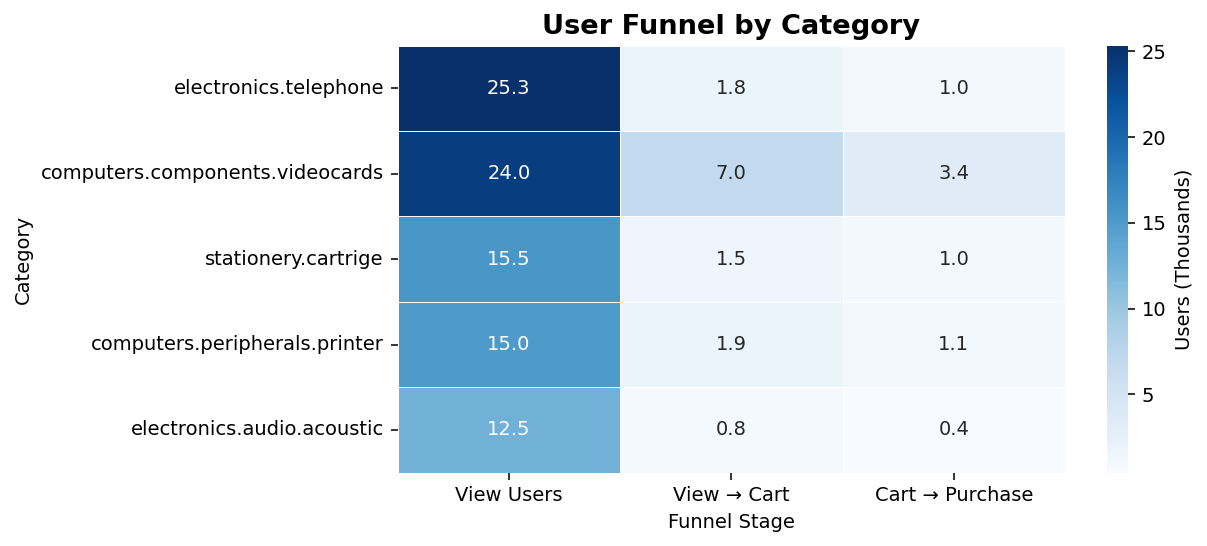

In [ ]:
top_categories = (
    category_funnel
    .sort_values("view_users", ascending=False)
    .head(5)
)

# metrics
funnel_heatmap = (
    top_categories[
        [
            "category_code",
            "view_users",
            "cart_users",
            "purchase_users"
        ]
    ]
    .set_index("category_code")
)

# Rename kolom
funnel_heatmap.columns = [
    "View Users",
    "View → Cart",
    "Cart → Purchase"
]

funnel_heatmap_display = funnel_heatmap / 1000

plt.figure(figsize=(9, 4), dpi=140)

sns.heatmap(
    funnel_heatmap_display,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Users (Thousands)"}
)

plt.title(
    "User Funnel by Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Category")

plt.tight_layout()

# plt.savefig(
#     "category.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

In [ ]:
# view_to_cart category conversion and dropoff

category_funnel["view_to_cart_conversion"] = (
    category_funnel["cart_users"]
    / category_funnel["view_users"]
    * 100
)

category_funnel["view_to_cart_dropoff"] = (
    100 - category_funnel["view_to_cart_conversion"]
)

# cart_to_purchase category conversion % dropoff
category_funnel["cart_to_purchase_conversion"] = (
    category_funnel["purchase_users"]
    / category_funnel["cart_users"]
    * 100
)

category_funnel["cart_to_purchase_dropoff"] = (
    100 - category_funnel["cart_to_purchase_conversion"]
)

category_funnel.sort_values(
    "view_users",
    ascending=False
).head(10)

,category_code,view_users,cart_users,purchase_users,view_to_cart_conversion,view_to_cart_dropoff,cart_to_purchase_conversion,cart_to_purchase_dropoff
87,electronics.telephone,25338,1789,953,7.06,92.94,53.27,46.73
45,computers.components.videocards,24011,6981,3404,29.07,70.93,48.76,51.24
101,stationery.cartrige,15508,1510,951,9.74,90.26,62.98,37.02
57,computers.peripherals.printer,15039,1897,1112,12.61,87.39,58.62,41.38
76,electronics.audio.acoustic,12504,825,425,6.60,93.40,51.52,48.48
89,electronics.video.tv,11042,455,190,4.12,95.88,41.76,58.24
40,computers.components.motherboard,10087,1489,709,14.76,85.24,47.62,52.38
38,computers.components.cpu,9905,1550,658,15.65,84.35,42.45,57.55
50,computers.notebook,9847,931,567,9.45,90.55,60.90,39.10
86,electronics.tablet,7557,587,313,7.77,92.23,53.32,46.68


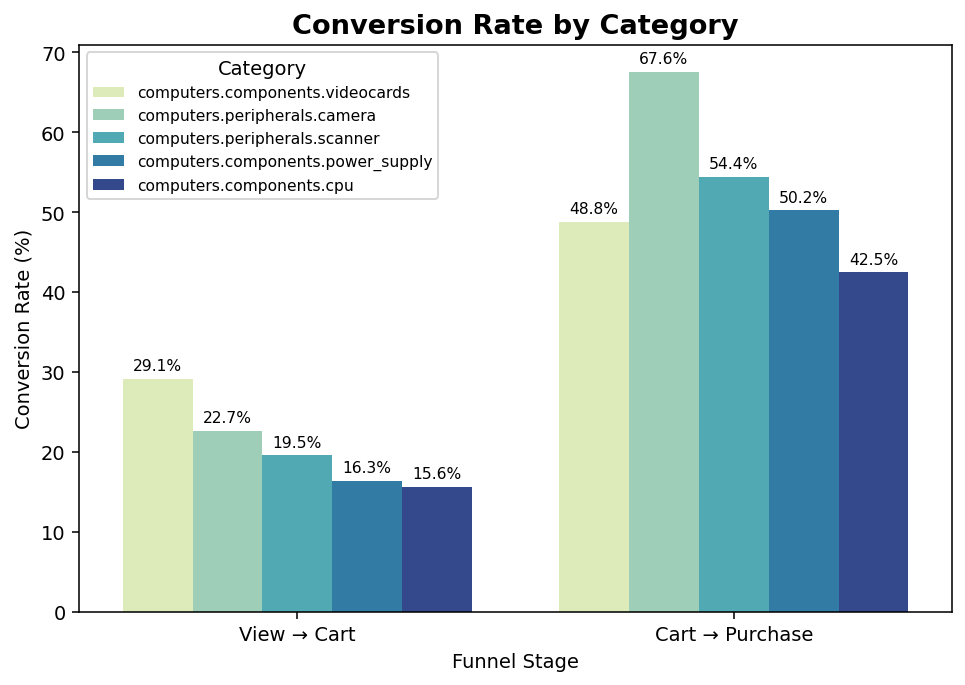

In [ ]:
top5_category = (
    category_funnel
    .sort_values("view_to_cart_conversion", ascending=False)
    .head(5)
)

# Plotting data
category_plot = top5_category[
    [
        "category_code",
        "view_to_cart_conversion",
        "cart_to_purchase_conversion"
    ]
].copy()

category_plot = category_plot.melt(
    id_vars="category_code",
    value_vars=[
        "view_to_cart_conversion",
        "cart_to_purchase_conversion"
    ],
    var_name="funnel_stage",
    value_name="conversion_rate"
)

# Rename funnel stage
category_plot["funnel_stage"] = category_plot["funnel_stage"].map({
    "view_to_cart_conversion": "View → Cart",
    "cart_to_purchase_conversion": "Cart → Purchase"
})

plt.figure(figsize=(7, 5), dpi=140)

ax = sns.barplot(
    data=category_plot,
    x="funnel_stage",
    y="conversion_rate",
    hue="category_code",
    palette='YlGnBu'
)

# bar labelling
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.title(
    "Conversion Rate by Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

plt.legend(
    title="Category",
    fontsize=8
)

plt.tight_layout()

# plt.savefig(
#     "category_conv.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )
plt.show()

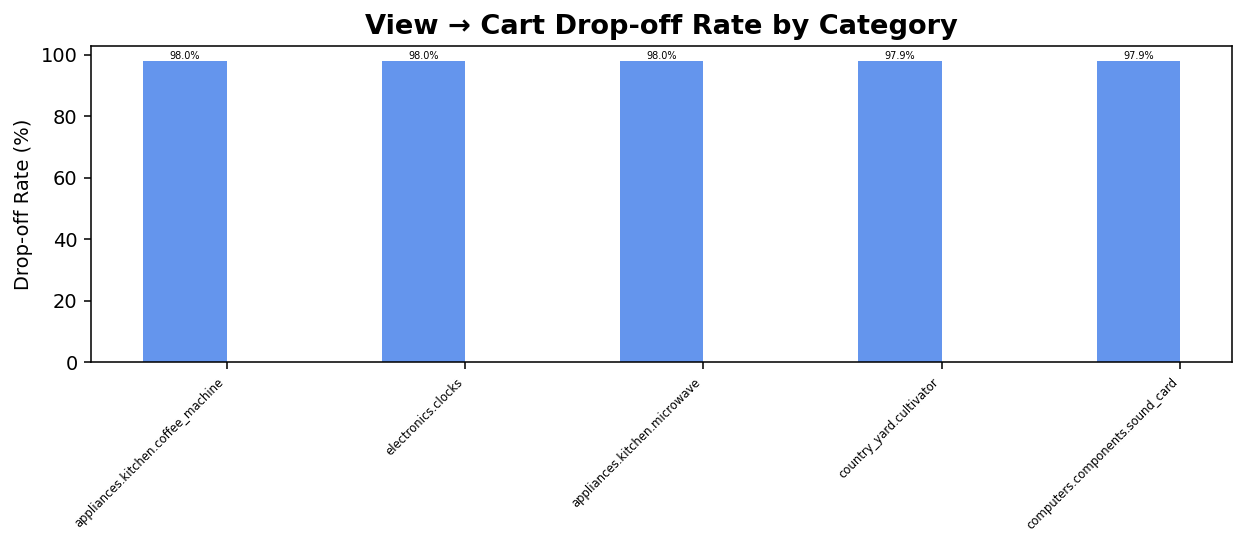

In [ ]:
# visualization of category drop off rate
top_dropoff_category = (
    category_funnel[
        category_funnel["view_users"] >= 1000
    ]
    .sort_values(
        "view_to_cart_dropoff",
        ascending=False
    )
    .head(5)
)

x = np.arange(len(top_dropoff_category))
width = 0.35

plt.figure(figsize=(9, 4), dpi=140)

bars = plt.bar(
    x - width/2,
    top_dropoff_category["view_to_cart_dropoff"],
    width,
    color='cornflowerblue',
    label="View → Cart"
)

for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=5
        )

plt.xticks(
    x,
    top_dropoff_category["category_code"],
    rotation=45,
    fontsize=6,
    ha="right"
)

plt.ylabel("Drop-off Rate (%)")

plt.title(
    "View → Cart Drop-off Rate by Category",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

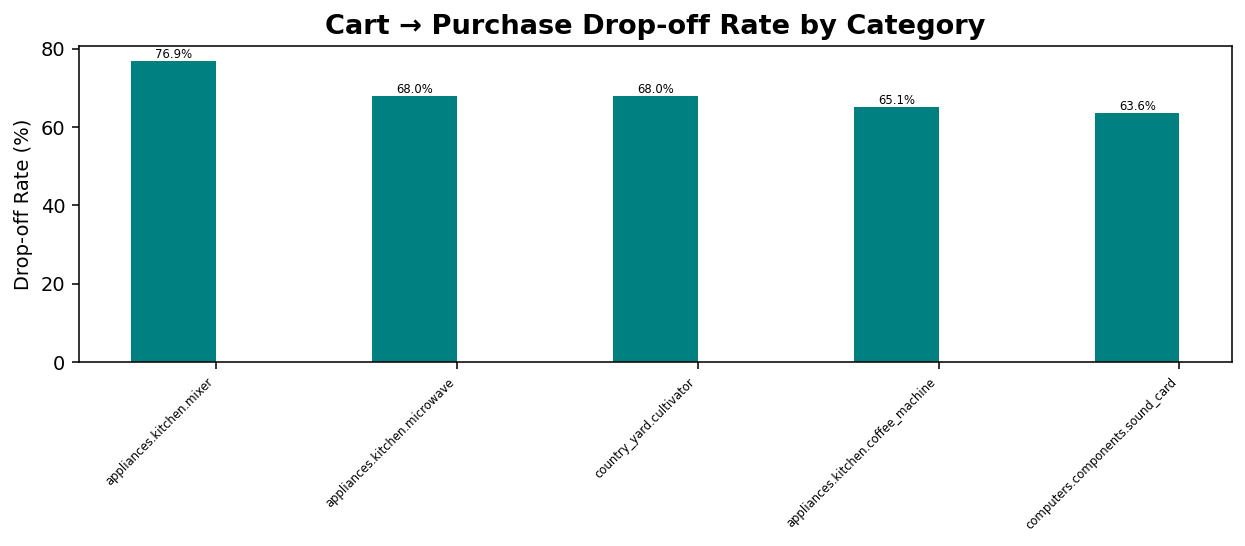

In [ ]:
top_dropoff_category = (
    category_funnel[
        category_funnel["view_users"] >= 1000
    ]
    .sort_values(
        "cart_to_purchase_dropoff",
        ascending=False
    )
    .head(5)
)

x = np.arange(len(top_dropoff_category))
width = 0.35

plt.figure(figsize=(9, 4), dpi=140)

bars = plt.bar(
    x - width/2,
    top_dropoff_category["cart_to_purchase_dropoff"],
    width,
    color='teal',
    label="Cart → Purchase"
)

for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=6
        )
plt.xticks(
    x,
    top_dropoff_category["category_code"],
    rotation=45,
    fontsize=6,
    ha="right"
)

plt.ylabel("Drop-off Rate (%)")

plt.title(
    "Cart → Purchase Drop-off Rate by Category",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

> Raw finding:

* View → Cart is the primary drop-off point across product categories among more than 1,000 views, appliance kithen (coffee machine & microwave) and electronic.clocks have the highest View-to-Cart drop-off rate (98%).

* Meanwhile, mixer contributes 76.9% drop-off rate in Cart-to-Purchase.
* Based on user funnel, electronic telephone drops the largest number of users in view to cart stage.

Summary:

Category-level funnel analysis shows that View-to-Cart is the primary drop-off stage. Among categories with more than 1,000 views, several categories record drop-off rates above 90%, with coffee machine, microwave, and clocks reaching 99.6%. Cart-to-Purchase drop-off is also substantial, reaching nearly 77% in kitchen appliance (mixer).

...............

####c. Brand

In [ ]:
brand_analysis = (
    data_clean[
        data_clean["event_type"].isin(["view", "cart", "purchase"])
    ]
    .groupby(["brand", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["view", "cart", "purchase"], fill_value=0)
    .reset_index()
)

brand_analysis.head()

event_type,brand,view,cart,purchase
0,accord,215,51,30
1,acer,510,28,21
2,achi,11,0,0
3,acmepower,10,0,0
4,acqua,2,0,0


In [ ]:
# make sure users follow the right funnel

brand_sorted = data_clean.sort_values(
    ["user_id", "event_time"]
).copy()

brand_events = (
    brand_sorted[
        brand_sorted["event_type"].isin(["view", "cart", "purchase"])
    ]
    .groupby(
        ["user_id", "brand", "event_type"]
    )["event_time"]
    .min()
    .unstack()
    .reindex(columns=["view", "cart", "purchase"], fill_value=0)
    .reset_index()
)

brand_events.head()

event_type,user_id,brand,view,cart,purchase
0,1515915625353226922,honor,2020-10-29 11:28:35,NaT,NaT
1,1515915625353230683,bbk,2020-11-09 09:22:00,NaT,NaT
2,1515915625353230683,canon,2020-12-12 10:33:09,NaT,NaT
3,1515915625353230683,canyon,2020-11-09 09:26:38,NaT,NaT
4,1515915625353230683,creative,2020-11-18 10:51:35,NaT,NaT


In [ ]:
brand_events = brand_events[
    brand_events["brand"].notna()
].copy()

brand_events["view_to_cart"] = (
    brand_events["view"].notna() &
    brand_events["cart"].notna() &
    (brand_events["cart"] > brand_events["view"])
)

brand_events["cart_to_purchase"] = (
    brand_events["cart"].notna() &
    brand_events["purchase"].notna() &
    (brand_events["purchase"] > brand_events["cart"])
)

brand_funnel = (
    brand_events
    .groupby("brand")
    .agg(
        viewers=("view", "count"),
        view_cart_users=("view_to_cart", "sum"),
        cart_purchase_users=("cart_to_purchase", "sum")
    )
    .reset_index()
)
brand_funnel.sort_values(
    "viewers",
    ascending=False
).head(10)

,brand,viewers,view_cart_users,cart_purchase_users
43,asus,11790,1597,766
559,samsung,11522,616,327
481,palit,9894,1806,724
222,gigabyte,9425,2350,1071
95,canon,9234,1016,575
24,amd,7880,1310,555
427,msi,7716,2198,1065
264,hp,6083,616,384
584,sirius,5745,713,429
495,pioneer,4365,475,253


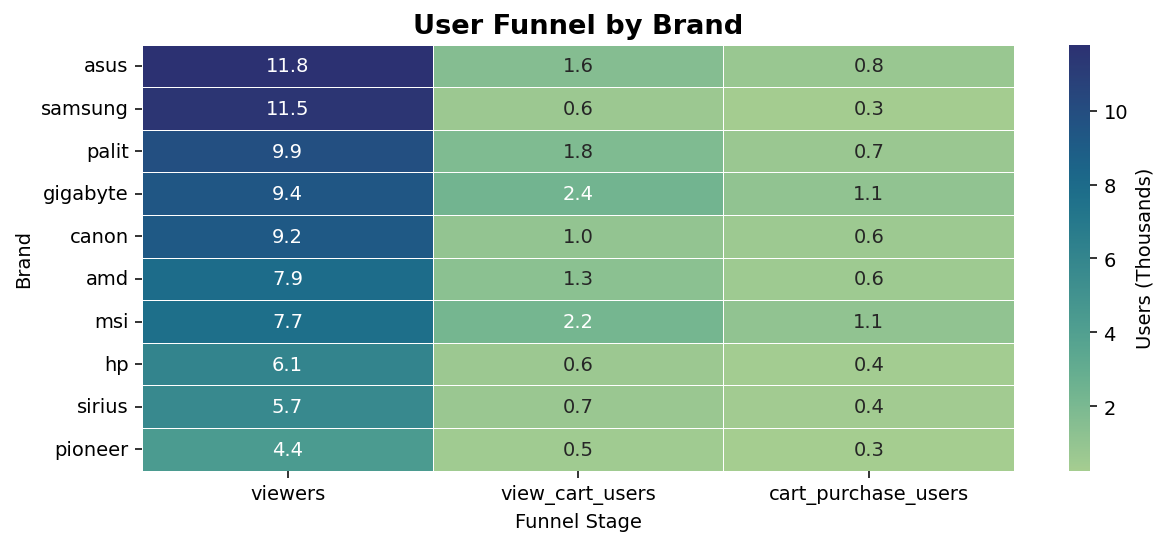

In [ ]:
top_brands = (
    brand_funnel
    .sort_values("viewers", ascending=False)
    .head(10)
)

# metrics
brand_heatmap = (
    top_brands[
        [
            "brand",
            "viewers",
            "view_cart_users",
            "cart_purchase_users"
        ]
    ]
    .set_index("brand")
)

brand_heatmap_display = brand_heatmap / 1000

plt.figure(figsize=(9, 4), dpi=140)

sns.heatmap(
    brand_heatmap_display,
    annot=True,
    fmt=".1f",
    cmap="crest",
    linewidths=0.5,
    cbar_kws={"label": "Users (Thousands)"}
)

plt.title(
    "User Funnel by Brand",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [ ]:
# view_to_cart brand conversion vs dropoff

brand_funnel["view_to_cart_conversion"] = (
    brand_funnel["view_cart_users"]
    / brand_funnel["viewers"]
    * 100
)

brand_funnel["view_to_cart_dropoff"] = (
    100 - brand_funnel["view_to_cart_conversion"]
)

# cart_to_purchase brand conversion & dropoff
brand_funnel["cart_to_purchase_conversion"] = (
    brand_funnel["cart_purchase_users"]
    / brand_funnel["view_cart_users"]
    * 100
)

brand_funnel["cart_to_purchase_dropoff"] = (
    100 - brand_funnel["cart_to_purchase_conversion"]
)

# overall conversion (from view to purchase)
brand_funnel["view_to_purchase_conversion"] = (
    brand_funnel["cart_purchase_users"]
    / brand_funnel["viewers"]
    * 100
)

brand_funnel.sort_values(
    "viewers",
    ascending=False
).head(10)

,brand,viewers,view_cart_users,cart_purchase_users,view_to_cart_conversion,view_to_cart_dropoff,cart_to_purchase_conversion,cart_to_purchase_dropoff,view_to_purchase_conversion
43,asus,11790,1597,766,13.55,86.45,47.96,52.04,6.50
559,samsung,11522,616,327,5.35,94.65,53.08,46.92,2.84
481,palit,9894,1806,724,18.25,81.75,40.09,59.91,7.32
222,gigabyte,9425,2350,1071,24.93,75.07,45.57,54.43,11.36
95,canon,9234,1016,575,11.00,89.00,56.59,43.41,6.23
24,amd,7880,1310,555,16.62,83.38,42.37,57.63,7.04
427,msi,7716,2198,1065,28.49,71.51,48.45,51.55,13.80
264,hp,6083,616,384,10.13,89.87,62.34,37.66,6.31
584,sirius,5745,713,429,12.41,87.59,60.17,39.83,7.47
495,pioneer,4365,475,253,10.88,89.12,53.26,46.74,5.80


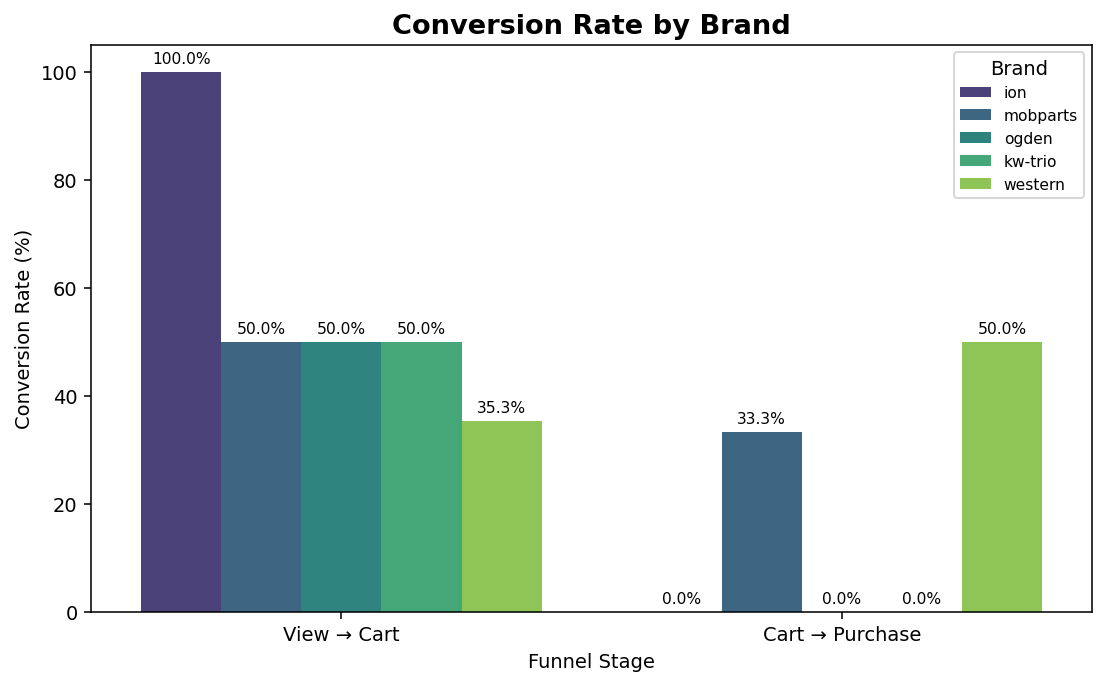

In [ ]:
# Top 5 brands conversion rate based on view users
top5_brand = (
    brand_funnel
    .sort_values("view_to_cart_conversion", ascending=False)
    .head(5)
)

# Plotting data
brand_plot = top5_brand[
    [
        "brand",
        "view_to_cart_conversion",
        "cart_to_purchase_conversion"
    ]
].copy()

brand_plot = brand_plot.melt(
    id_vars="brand",
    value_vars=[
        "view_to_cart_conversion",
        "cart_to_purchase_conversion"
    ],
    var_name="funnel_stage",
    value_name="conversion_rate"
)

# Rename funnel stage
brand_plot["funnel_stage"] = brand_plot["funnel_stage"].map({
    "view_to_cart_conversion": "View → Cart",
    "cart_to_purchase_conversion": "Cart → Purchase"
})

plt.figure(figsize=(8, 5), dpi=140)

ax = sns.barplot(
    data=brand_plot,
    x="funnel_stage",
    y="conversion_rate",
    hue="brand",
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.title(
    "Conversion Rate by Brand",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

plt.legend(
    title="Brand",
    fontsize=8
)

plt.tight_layout()

# plt.savefig(
#     "brand_conv.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()

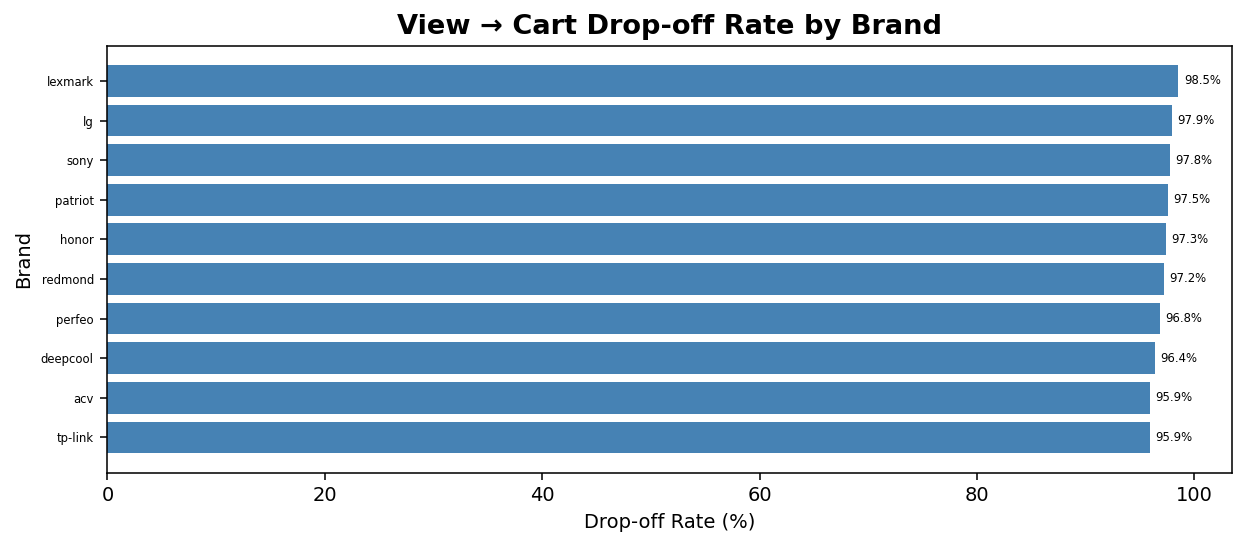

In [ ]:
# Brand drop off rate
top_dropoff_brand = (
    brand_funnel[
        brand_funnel["viewers"] >= 1000
    ]
    .sort_values(
        "view_to_cart_dropoff",
        ascending=False
    )
    .head(10)
)

y = np.arange(len(top_dropoff_brand))

plt.figure(figsize=(9, 4), dpi=140)

bars = plt.barh(
    y,
    top_dropoff_brand["view_to_cart_dropoff"],
    color="steelblue",
    label="View → Cart"
)

for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            ha="left",
            va="center",
            fontsize=6
        )

plt.yticks(
    y,
    top_dropoff_brand["brand"],
    fontsize=6
)

plt.gca().invert_yaxis()
plt.xlabel("Drop-off Rate (%)")
plt.ylabel("Brand")

plt.title(
    "View → Cart Drop-off Rate by Brand",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

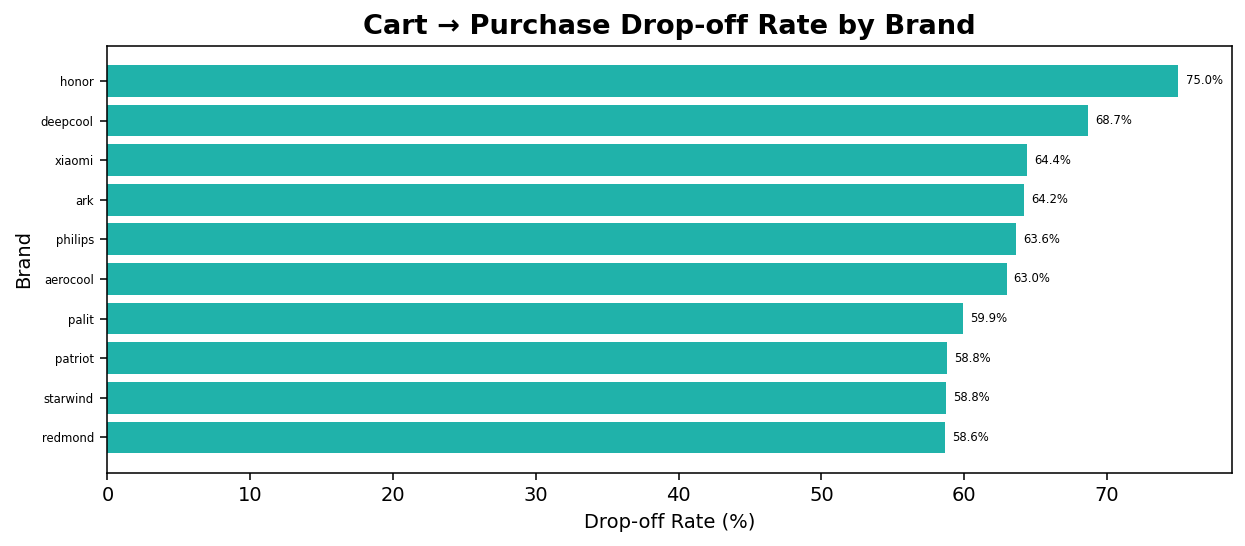

In [ ]:
top_dropoff_brand = (
    brand_funnel[
        brand_funnel["viewers"] >= 1000
    ]
    .sort_values(
        "cart_to_purchase_dropoff",
        ascending=False
    )
    .head(10)
)

x = np.arange(len(top_dropoff_brand))

plt.figure(figsize=(9, 4), dpi=140)

bars = plt.barh(
    y,
    top_dropoff_brand["cart_to_purchase_dropoff"],
    color='lightseagreen',
    label="cart → purchase"
)

for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            ha="left",
            va="center",
            fontsize=6
        )

plt.yticks(
    y,
    top_dropoff_brand["brand"],
    fontsize=6
)

plt.xlabel("Drop-off Rate (%)")
plt.ylabel("Brand")

plt.gca().invert_yaxis()

plt.title(
    "Cart → Purchase Drop-off Rate by Brand",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

> finding:
* View → Cart still dominates the exit point across brands among more than 1,000 views, with lexmark contributes to the highest drop-off rate (98.5%), and honor contributes 75% drop-off rates in Cart-to-Purchase.

* Based on user volume, Samsung & Asus drop the largest number of users in view to cart stage.

# Customer Journey
> Q1: How much consideration happens before customers add a product to cart?

> Q2: How long does it take customers to make a purchase decision?




##1.Time-to-Cart

In [ ]:
df2 = data_clean.sort_values(
    ["user_id", "product_id", "event_time"]
).copy()

# First time user viewed a product
first_view = (
    df2[df2["event_type"] == "view"]
    .groupby(["user_id", "product_id"])
    .agg(
        first_view=("event_time", "min")
    )
    .reset_index()
)

# First time user added the same product to cart
first_cart = (
    df2[df2["event_type"] == "cart"]
    .groupby(["user_id", "product_id"])
    .agg(
        cart_time=("event_time", "min")
    )
    .reset_index()
)

# Match first view with first cart
view_cart = first_view.merge(
    first_cart,
    on=["user_id", "product_id"],
    how="inner"
)

# cart must happens after first view
view_cart = view_cart[
    view_cart["cart_time"] > view_cart["first_view"]
].copy()

# Calculate time-to-cart
view_cart["time_to_cart_hours"] = (
    view_cart["cart_time"] -
    view_cart["first_view"]
).dt.total_seconds() / 3600

display(
    view_cart[
        [
            "user_id",
            "product_id",
            "first_view",
            "cart_time",
            "time_to_cart_hours"
        ]
    ].head(5)
)

,user_id,product_id,first_view,cart_time,time_to_cart_hours
0,1515915625353286099,1023383,2020-10-03 11:20:33,2020-10-03 11:23:00,0.04
1,1515915625353286099,4035841,2020-10-06 08:27:47,2020-10-06 08:28:18,0.01
2,1515915625353457259,137302,2020-09-29 05:51:33,2020-09-29 05:51:58,0.01
3,1515915625353534622,1428321,2020-10-06 08:29:35,2020-10-06 09:45:38,1.27
4,1515915625353561691,1507368,2020-11-24 17:34:42,2020-11-24 17:35:50,0.02


In [ ]:
time_to_cart_summary = (
    view_cart["time_to_cart_hours"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(time_to_cart_summary)

,time_to_cart_hours
count,"28,991.00"
mean,12.11
std,94.00
min,0.00
25%,0.01
50%,0.02
75%,0.07
90%,0.59
95%,18.49
99%,339.83


> Interpretation:

* mean : 12 hours 7 minutes
* median : 1.2 minutes
* Q75 : 4.2 minutes
* Q90 : 35.4 minutes
* Q95 : 18 hours 29 minutes
* Q99 : 14.2 days
* max : 110 days

> Finding:

Generally, consideration process from viewing products to cart is very short, with a median of 1.2 minutes and the Q90 is only 35 minutes.

However, there is a wide interval from q90 to q95 and q99, indicating small portion of customers needs longer time to consider.

Summary:
* Customers typically add a product to cart within minutes, while a small segment exhibits substantially longer consideration cycles.
* Even though view to cart stage is the biggest drop-off points across funnel, but users who successfully progress to the cart generally do it in short time.

##2.Time-to-Purchase

In [ ]:
df2 = data_clean.sort_values(
    ["user_id", "product_id", "event_time"]
).copy()

# First time user viewed a product
first_view = (
    df2[df2["event_type"] == "view"]
    .groupby(["user_id", "product_id"])
    .agg(
        first_view=("event_time", "min")
    )
    .reset_index()
)

# First time user purchased the same product
first_purchase = (
    df2[df2["event_type"] == "purchase"]
    .groupby(["user_id", "product_id"])
    .agg(
        purchase_time=("event_time", "min"),
        purchase_price=("price", "first"),
        category_code=("category_code", "first"),
        brand=("brand", "first")
    )
    .reset_index()
)

# Match first view with first purchase
time_purchase = first_view.merge(
    first_purchase,
    on=["user_id", "product_id"],
    how="inner"
)

# Purchase must happen after the first view
time_purchase = time_purchase[
    time_purchase["purchase_time"] > time_purchase["first_view"]
].copy()

# Calculate time-to-purchase
time_purchase["time_to_purchase_hours"] = (
    time_purchase["purchase_time"] -
    time_purchase["first_view"]
).dt.total_seconds() / 3600

display(
    time_purchase[
        [
            "user_id",
            "product_id",
            "category_code",
            "brand",
            "purchase_price",
            "first_view",
            "purchase_time",
            "time_to_purchase_hours"
        ]
    ].head(5)
)

,user_id,product_id,category_code,brand,purchase_price,first_view,purchase_time,time_to_purchase_hours
0,1515915625353286099,1023383,computers.peripherals.wifi,zyxel,119.03,2020-10-03 11:20:33,2020-10-03 11:23:44,0.05
1,1515915625353457259,137302,computers.components.motherboard,asus,55.16,2020-09-29 05:51:33,2020-09-29 05:52:55,0.02
2,1515915625353534622,1428321,electronics.tablet,samsung,19.05,2020-10-06 08:29:35,2020-10-06 10:01:55,1.54
3,1515915625353561691,1507368,computers.peripherals.wifi,keenetic,172.86,2020-11-24 17:34:42,2020-11-24 17:37:22,0.04
4,1515915625353900095,16237,computers.peripherals.camera,sven,18.10,2020-10-15 05:07:14,2020-10-15 05:09:35,0.04


In [ ]:
ttp_summary = (
    time_purchase["time_to_purchase_hours"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(ttp_summary)

,time_to_purchase_hours
count,"14,607.00"
mean,18.16
std,112.20
min,0.00
25%,0.03
50%,0.08
75%,0.34
90%,9.64
95%,56.55
99%,482.89


> Interpretation:

* mean : 18 hours 16 minutes
* median decision time : 4.4 minutes
* Q75 : 20.4 minutes
* Q90 : 9 hours 38 minutes
* Q95 : ~ 2.4 days
* Q99 : ~ 20 days
* max : 110 days

> Finding:

Customer purchase decisions are highly right-skewed. While the median time-to-purchase is only 4.8 minutes, the mean reaches more than 18 hours, indicating a long tail.

The extended long tail suggests that customer decision time is heterogeneous, making Q90 more informative than the mean for identifying high-consideration purchase behavior. The distribution is displayed in log-scale transformation for better visualization.

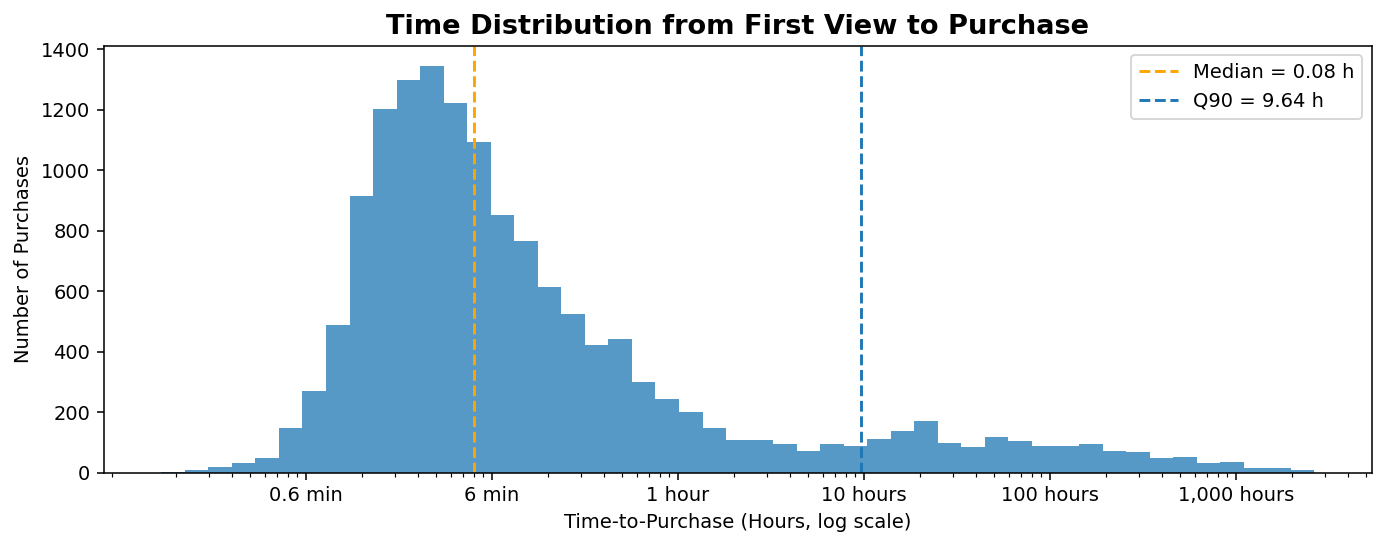

In [ ]:
ttp_q90 = time_purchase[
    time_purchase["time_to_purchase_hours"] > 0
].copy()

# Buat logarithmic bins
log_bins = np.logspace(
    np.log10(ttp_q90["time_to_purchase_hours"].min()),
    np.log10(ttp_q90["time_to_purchase_hours"].max()),
    50
)

median_ttp = ttp_q90["time_to_purchase_hours"].median()
q90 = ttp_q90["time_to_purchase_hours"].quantile(0.90)

plt.figure(figsize=(10, 4), dpi=140)

sns.histplot(
    ttp_q90["time_to_purchase_hours"],
    bins=log_bins
)

plt.xscale("log")

# Custom X-axis
ticks = [
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

labels = [
    "0.6 min",
    "6 min",
    "1 hour",
    "10 hours",
    "100 hours",
    "1,000 hours"
]

plt.xticks(ticks, labels)

plt.axvline(
    median_ttp,
    linestyle="--",
    color='orange',
    label=f"Median = {median_ttp:.2f} h"
)

plt.axvline(
    q90,
    linestyle="--",
    label=f"Q90 = {q90:.2f} h"
)

plt.title(
    "Time Distribution from First View to Purchase",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time-to-Purchase (Hours, log scale)")
plt.ylabel("Number of Purchases")

plt.legend()

plt.tight_layout()
plt.show()

> Finding:

Most customers make purchase decisions within a relatively short period after their first product view, with median 4.8 minutes, while a smaller segment shows substantially longer consideration cycles, creating a pronounced long-tail distribution.

##3.Return Visit

> Q: How many sessions do customers typically go through before proceeding to the next stage?

In [ ]:
journey_to_cart = df2.merge(
    view_cart[
        [
            "user_id",
            "product_id",
            "cart_time"
        ]
    ],
    on=["user_id", "product_id"],
    how="inner"
)

journey_to_cart = journey_to_cart[
    journey_to_cart["event_time"] <=
    journey_to_cart["cart_time"]
].copy()

return_visit = (
    journey_to_cart
    .groupby(["user_id", "product_id"])
    ["user_session"]
    .nunique()
    .reset_index(name="sessions_before_cart")
)

display(return_visit.head(5))


,user_id,product_id,sessions_before_cart
0,1515915625353286099,1023383,1
1,1515915625353286099,4035841,1
2,1515915625353457259,137302,1
3,1515915625353534622,1428321,1
4,1515915625353561691,1507368,2


In [ ]:
# Return visit distribution

return_visit_distribution = (
    return_visit["sessions_before_cart"]
    .value_counts()
    .sort_index()
    .reset_index()
)

return_visit_distribution.columns = [
    "sessions_before_cart",
    "users"
]

return_visit_distribution["percentage"] = (
    return_visit_distribution["users"]
    / return_visit_distribution["users"].sum()
    * 100
)

display(return_visit_distribution)

,sessions_before_cart,users,percentage
0,1,24316,83.87
1,2,4059,14.00
2,3,388,1.34
3,4,125,0.43
4,5,49,0.17
5,6,26,0.09
6,7,4,0.01
7,8,8,0.03
8,9,3,0.01
9,10,5,0.02


In [ ]:
return_visit["return_visit_band"] = pd.cut(
    return_visit["sessions_before_cart"],
    bins=[0, 1, 2, np.inf],
    labels=[
        "1 session",
        "2 sessions",
        "3+ sessions"
    ]
)

return_visit_band = (
    return_visit["return_visit_band"]
    .value_counts(sort=False)
    .reset_index()
)

return_visit_band.columns = [
    "return_visit_band",
    "users"
]

return_visit_band["percentage"] = (
    return_visit_band["users"]
    / return_visit_band["users"].sum()
    * 100
)

display(return_visit_band)

,return_visit_band,users,percentage
0,1 session,24316,83.87
1,2 sessions,4059,14.00
2,3+ sessions,616,2.12


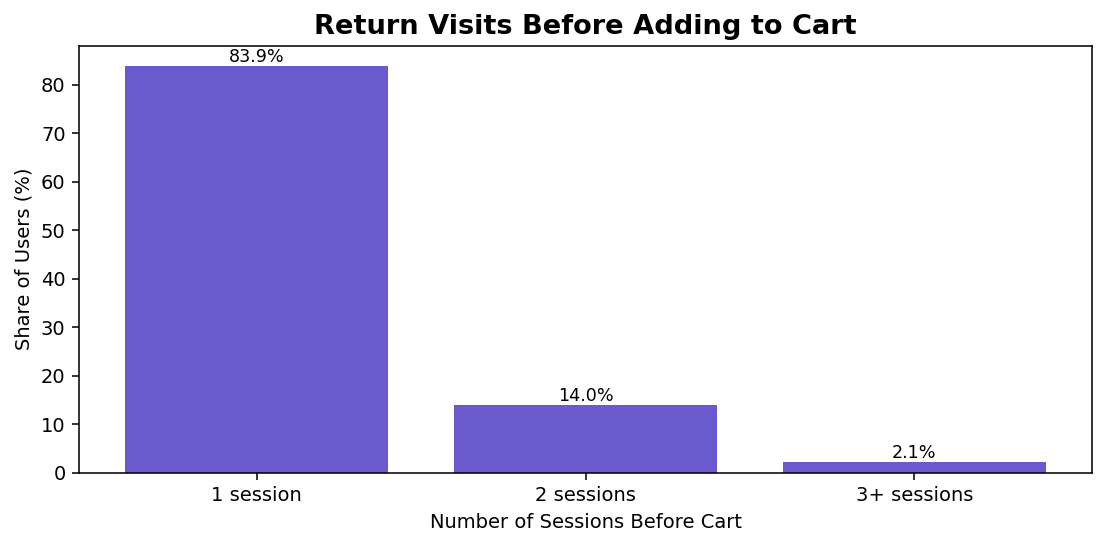

In [ ]:
plt.figure(figsize=(8, 4), dpi=140)

bars = plt.bar(
    return_visit_band["return_visit_band"],
    return_visit_band["percentage"],
    color='slateblue'
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Return Visits Before Adding to Cart",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Sessions Before Cart")
plt.ylabel("Share of Users (%)")

plt.tight_layout()
plt.show()

In [ ]:
journey_to_purchase = df2.merge(
    time_purchase[
        [
            "user_id",
            "product_id",
            "first_view",
            "purchase_time"
        ]
    ],
    on=["user_id", "product_id"],
    how="inner"
)

journey_to_purchase = journey_to_purchase[
    journey_to_purchase["event_time"] <=
    journey_to_purchase["purchase_time"]
].copy()

return_visit_purchase = (
    journey_to_purchase
    .groupby(["user_id", "product_id"])
    ["user_session"]
    .nunique()
    .reset_index(name="sessions_before_purchase")
)

display(return_visit_purchase.head(5))

,user_id,product_id,sessions_before_purchase
0,1515915625353286099,1023383,1
1,1515915625353457259,137302,1
2,1515915625353534622,1428321,1
3,1515915625353561691,1507368,2
4,1515915625353900095,16237,1


In [ ]:
time_purchase = time_purchase.merge(
    return_visit_purchase,
    on=["user_id", "product_id"],
    how="left"
)

display(
    time_purchase[
        [
            "user_id",
            "product_id",
            "category_code",
            "purchase_price",
            "time_to_purchase_hours",
            "sessions_before_purchase"
        ]
    ].head(5)
)

,user_id,product_id,category_code,purchase_price,time_to_purchase_hours,sessions_before_purchase
0,1515915625353286099,1023383,computers.peripherals.wifi,119.03,0.05,1
1,1515915625353457259,137302,computers.components.motherboard,55.16,0.02,1
2,1515915625353534622,1428321,electronics.tablet,19.05,1.54,1
3,1515915625353561691,1507368,computers.peripherals.wifi,172.86,0.04,2
4,1515915625353900095,16237,computers.peripherals.camera,18.10,0.04,1


In [ ]:
return_visit_distribution = (
    time_purchase["sessions_before_purchase"]
    .value_counts()
    .sort_index()
    .reset_index()
)

return_visit_distribution.columns = [
    "sessions_before_purchase",
    "users"
]

return_visit_distribution["percentage"] = (
    return_visit_distribution["users"]
    / return_visit_distribution["users"].sum()
    * 100
)

display(return_visit_distribution)

,sessions_before_purchase,users,percentage
0,1,10711,73.33
1,2,3245,22.22
2,3,415,2.84
3,4,125,0.86
4,5,53,0.36
5,6,25,0.17
6,7,8,0.05
7,8,6,0.04
8,9,3,0.02
9,10,3,0.02


Finding:
> 1. Most customers who proceeded to cart, did it during the same session as their initial visit, suggesting that repeated return visits were not required for most cart additions.

> 2. Most purchases occur within a single session (73.3%), while 26.7% of customers return at least once before purchasing, suggesting that extended consideration through return visits is relevant for a smaller customer segment.

# Cohort Analysis

> Q: Which factors are statistically associated with the probability of conversion or drop-off?

In [ ]:
df_cohort = data_clean.copy()

df_cohort["event_date"] = pd.to_datetime(df_cohort["event_date"])

first_date = (
    df_cohort
    .groupby("user_id")["event_date"]
    .transform("min")
)

df_cohort["cohort_month"] = (
    first_date
    .dt.to_period("M")
    .dt.to_timestamp()
)

df_cohort["activity_month"] = (
    df_cohort["event_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df_cohort["cohort_index"] = (
    (df_cohort["activity_month"].dt.year -
     df_cohort["cohort_month"].dt.year) * 12
    +
    (df_cohort["activity_month"].dt.month -
     df_cohort["cohort_month"].dt.month)
)

In [ ]:
cohort_users = (
    df_cohort
    .groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .reset_index(name="users")
)

cohort_matrix = cohort_users.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="users"
)

cohort_matrix

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09-01,"8,041.00",519.00,131.00,56.00,56.00,39.00
2020-10-01,"44,400.00","1,160.00",339.00,207.00,133.00,NaN
2020-11-01,"49,307.00",924.00,401.00,263.00,NaN,NaN
2020-12-01,"38,431.00",946.00,335.00,NaN,NaN,NaN
2021-01-01,"44,513.00","1,327.00",NaN,NaN,NaN,NaN
2021-02-01,"40,279.00",NaN,NaN,NaN,NaN,NaN


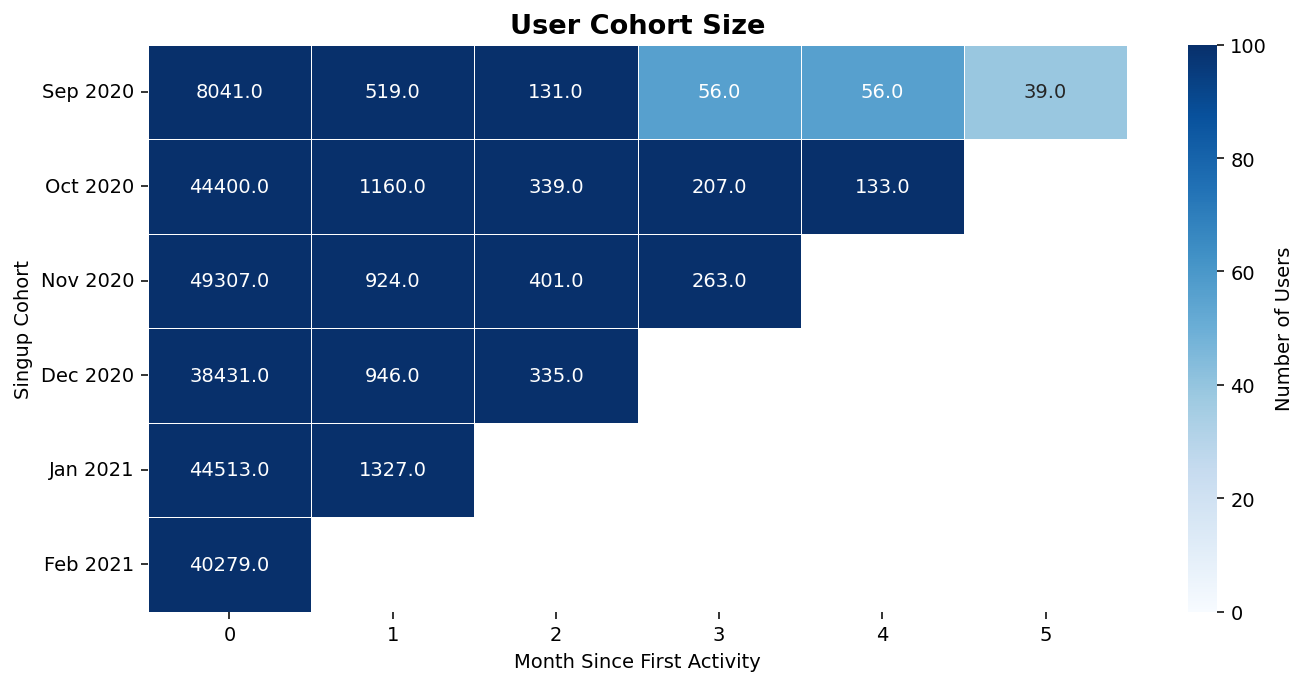

In [ ]:
cohort_plot = cohort_matrix.copy()
cohort_plot.index = cohort_plot.index.strftime('%b %Y')

plt.figure(figsize=(10, 5), dpi=140)

sns.heatmap(
    cohort_plot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Number of Users"}
)

plt.title(
    "User Cohort Size",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month Since First Activity")
plt.ylabel("Singup Cohort")

plt.tight_layout()
plt.show()

##1.Retention Rate

In [ ]:
cohort_size = (
    cohort_users
    .query("cohort_index == 0")
    [["cohort_month", "users"]]
    .rename(columns={"users": "cohort_size"})
)

retention = cohort_users.merge(
    cohort_size,
    on="cohort_month"
)

retention["retention_rate"] = (
    retention["users"] /
    retention["cohort_size"] * 100
)

retention_matrix = (
    retention
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention_rate"
    )
)

display(retention_matrix.round(1))

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09-01,100.00,6.50,1.60,0.70,0.70,0.50
2020-10-01,100.00,2.60,0.80,0.50,0.30,NaN
2020-11-01,100.00,1.90,0.80,0.50,NaN,NaN
2020-12-01,100.00,2.50,0.90,NaN,NaN,NaN
2021-01-01,100.00,3.00,NaN,NaN,NaN,NaN
2021-02-01,100.00,NaN,NaN,NaN,NaN,NaN


In [ ]:
retention_plot = retention_matrix.copy()
retention_plot.index = retention_plot.index.strftime('%b %Y')

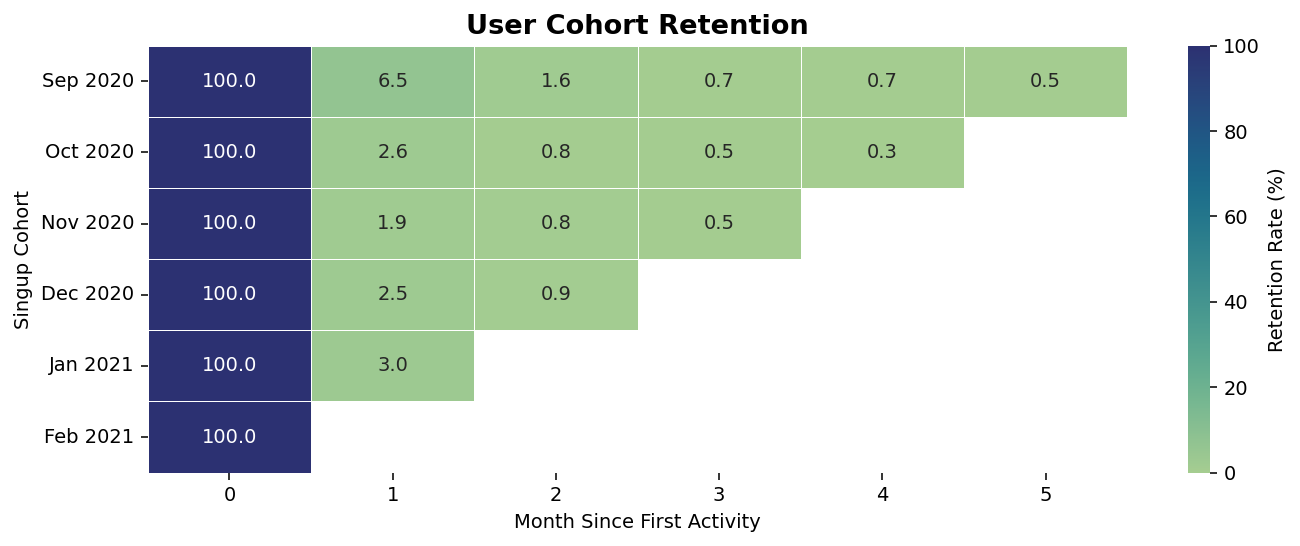

In [ ]:
plt.figure(figsize=(10, 4), dpi=140)

sns.heatmap(
    retention_plot,
    annot=True,
    fmt=".1f",
    cmap="crest",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title(
    "User Cohort Retention",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month Since First Activity")
plt.ylabel("Singup Cohort")

plt.tight_layout()
plt.show()

##2.Average Purchase Frequency

In [ ]:
purchase_cohort = df_cohort[
    df_cohort["event_type"] == "purchase"
].copy()

purchase_frequency = (
    purchase_cohort
    .groupby(
        ["cohort_month", "user_id"]
    )
    .size()
    .reset_index(name="purchase_count")
)

purchase_summary = (
    purchase_frequency
    .groupby("cohort_month")
    .agg(
        purchasing_users=("user_id", "nunique"),
        total_purchases=("purchase_count", "sum"),
        avg_purchase_frequency=("purchase_count", "mean")
    )
    .reset_index()
)

display(purchase_summary)

,cohort_month,purchasing_users,total_purchases,avg_purchase_frequency
0,2020-09-01,430,775,1.80
1,2020-10-01,2204,3850,1.75
2,2020-11-01,2543,4562,1.79
3,2020-12-01,2294,4007,1.75
4,2021-01-01,3040,5444,1.79
5,2021-02-01,2530,4467,1.77


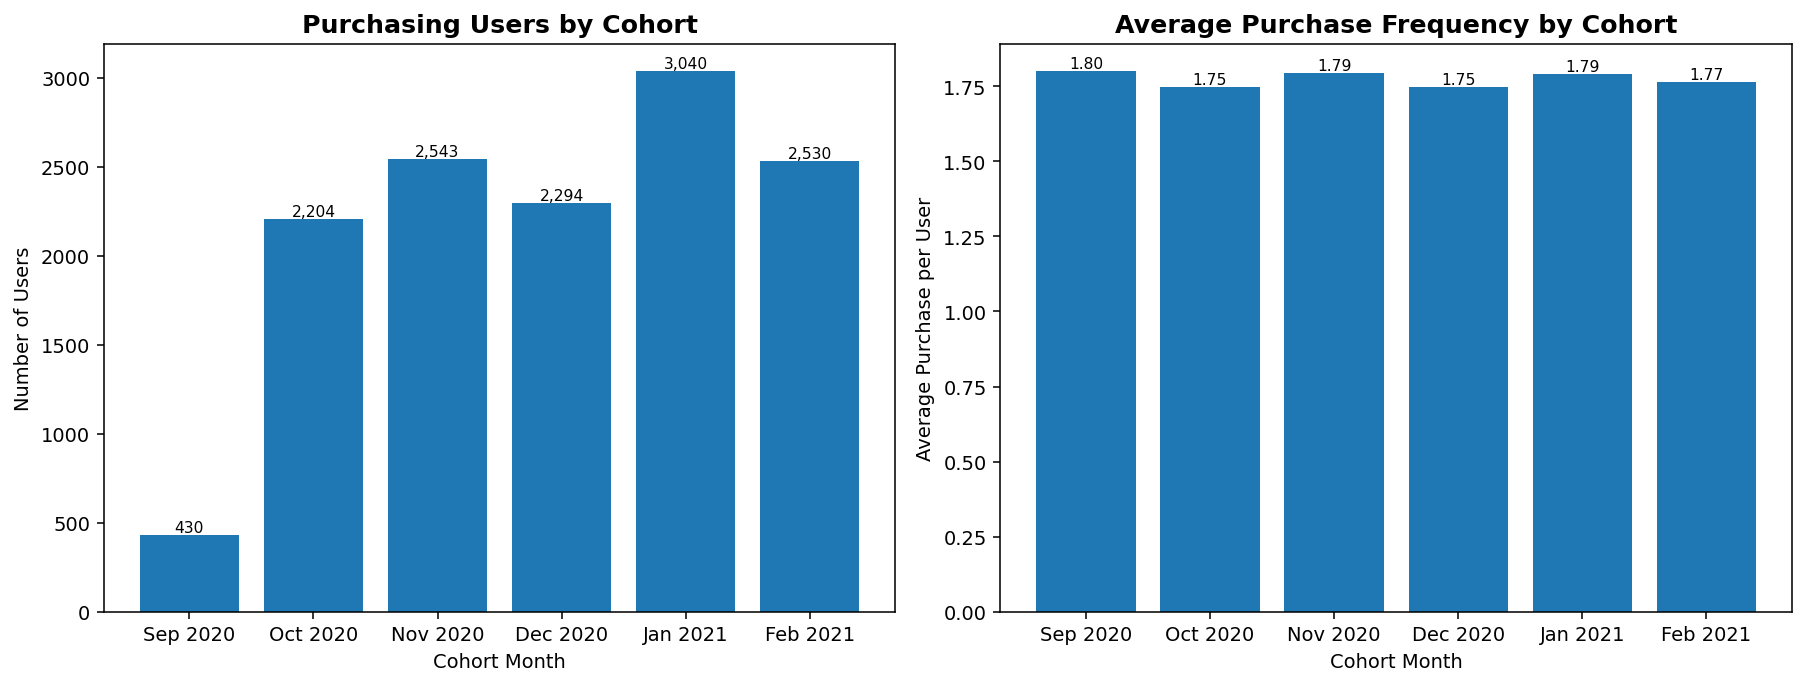

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=140)

# Purchasing users
bars1 = axes[0].bar(
    purchase_summary["cohort_month"].dt.strftime("%b %Y"),
    purchase_summary["purchasing_users"]
)

axes[0].set_title(
    "Purchasing Users by Cohort",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("Cohort Month")
axes[0].set_ylabel("Number of Users")

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# Purchase frequency
bars2 = axes[1].bar(
    purchase_summary["cohort_month"].dt.strftime("%b %Y"),
    purchase_summary["avg_purchase_frequency"]
)

axes[1].set_title(
    "Average Purchase Frequency by Cohort",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Cohort Month")
axes[1].set_ylabel("Average Purchase per User")

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

> finding:

The number of purchasing users varies across cohorts, reaching its highest level in January 2021. However, average purchase frequency remains stable at around 1.75–1.80 purchases per user, indicating limited variation in purchasing behaviour across cohorts.

# Import CSV for Power BI

In [ ]:
# Fact Events
fact_events = data_clean[
    [
        "event_time",
        "event_type",
        "product_id",
        "category_id",
        "category_code",
        "brand",
        "price",
        "user_id",
        "user_session",
        "event_date",
        "event_day",
        "event_hour",
        "price_band"
    ]
].copy()

# Export
# fact_events.to_csv(
#     "fact_events.csv",
#     index=False
# )
fact_events.to_excel(
    "fact_events.xlsx",
    index=False
)

# print("fact_events.csv berhasil dibuat")
# print(fact_events.shape)